<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-Defect-Detection-Experiments/84_accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
from google.colab import drive


drive.mount('/content/drive', force_remount=True)
print("✅ Drive Connected!")

zip_path = '/content/drive/MyDrive/Defects.zip'
extract_base = '/content/dataset/'

if not os.path.exists(extract_base):
    os.makedirs(extract_base)

print("📦 Extracting dataset... Please wait.")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_base)
    print("✅ Extraction Complete!\n")
except FileNotFoundError:
    print(f"❌ Error: {zip_path} ")


Mounted at /content/drive
✅ Drive Connected!
📦 Extracting dataset... Please wait.
✅ Extraction Complete!



In [ ]:
import cv2
import numpy as np
import glob
import gc

IMG_SIZE = 224
data_path = None


for root, dirs, files in os.walk(extract_base):
    if 'train' in dirs and 'valid' in dirs:
        data_path = os.path.dirname(root)
        break

if not data_path:
    print("❌ ")
else:
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    classes = [c for c in classes if not c.startswith('.')]
    classes.sort()
    class_map = {name: i for i, name in enumerate(classes)}
    print(f"🎯 Found Classes ({len(classes)}): {classes}\n")

    def load_custom_yolo_data(split_name):
        images, cls_labels, bboxes = [], [], []

        for category in classes:
            img_dir = os.path.join(data_path, category, split_name, 'images')
            lbl_dir = os.path.join(data_path, category, split_name, 'labels')

            if not os.path.exists(img_dir):
                continue

            img_paths = glob.glob(os.path.join(img_dir, "*.*"))
            img_paths = [f for f in img_paths if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]
            c_id = class_map[category]

            for img_path in img_paths:
                img = cv2.imread(img_path)
                if img is None: continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                images.append(np.array(img, dtype=np.float32) / 255.0)

                base_name = os.path.splitext(os.path.basename(img_path))[0]
                txt_path = os.path.join(lbl_dir, base_name + ".txt")

                bbox = [0.5, 0.5, 0.3, 0.3]

                if os.path.exists(txt_path):
                    with open(txt_path, 'r') as f:
                        lines = f.readlines()
                        if len(lines) > 0:
                            parts = lines[0].strip().split()
                            if len(parts) >= 5:

                                bbox = [float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])]

                cls_labels.append(c_id)
                bboxes.append(bbox)

        return np.array(images, dtype=np.float32), np.array(cls_labels), np.array(bboxes, dtype=np.float32)

    print("⏳ Training Data ලෝඩ් කරමින් පවතී...")
    X_train, y_cls_train, y_bbox_train = load_custom_yolo_data('train')

    print("⏳ Validation Data ලෝඩ් කරමින් පවතී...")
    X_valid, y_cls_valid, y_bbox_valid = load_custom_yolo_data('valid')

    print("⏳ Testing Data ලෝඩ් කරමින් පවතී...")
    X_test, y_cls_test, y_bbox_test = load_custom_yolo_data('test')

    print(f"\n🚀 Data Loading සම්පූර්ණයි!")
    print(f"   Train පින්තූර: {len(X_train)} | Valid පින්තූර: {len(X_valid)} | Test පින්තූර: {len(X_test)}")



🎯 Found Classes (7): ['Holes', 'Lines', 'Objects', 'Oil_Spot', 'Pinched_fabric', 'Stain', 'thread error']

⏳ Training Data ලෝඩ් කරමින් පවතී...
⏳ Validation Data ලෝඩ් කරමින් පවතී...
⏳ Testing Data ලෝඩ් කරමින් පවතී...

🚀 Data Loading සම්පූර්ණයි!
   Train පින්තූර: 2055 | Valid පින්තූර: 586 | Test පින්තූර: 293


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_fivora_high_accuracy():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Data Augmentation
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.2)(x)
    x = layers.RandomContrast(0.2)(x)

    # Base Model (MobileNetV2) - ✨ Fine-Tuning
    base = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    # Channel Attention
    channels = x.shape[-1]
    squeeze = layers.GlobalAveragePooling2D()(x)
    excitation = layers.Dense(channels // 8, activation='relu')(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid')(excitation)
    excitation = layers.Reshape((1, 1, channels))(excitation)
    x = layers.Multiply()([x, excitation])

    # Spatial Attention
    s = x.shape
    x_reshaped = layers.Reshape((s[1] * s[2], s[3]))(x)
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=s[3])(x_reshaped, x_reshaped)
    x_attended = layers.Add()([x_reshaped, attention])
    x_norm = layers.LayerNormalization()(x_attended)
    x_gap = layers.GlobalAveragePooling1D()(x_norm)

    # Anti-Overfitting
    x_drop = layers.Dropout(0.5)(x_gap)
    x_dense = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x_drop)
    x_final_drop = layers.Dropout(0.3)(x_dense)

    # Output Layers
    class_output = layers.Dense(len(classes), activation='softmax', name='class_output')(x_final_drop)
    bbox_output = layers.Dense(4, activation='sigmoid', name='bbox_output')(x_final_drop)

    model = models.Model(inputs=inputs, outputs=[class_output, bbox_output])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss={'class_output': 'sparse_categorical_crossentropy', 'bbox_output': 'mse'},
        metrics={'class_output': 'accuracy', 'bbox_output': 'mse'}
    )
    return model

if data_path:
    fivora_detector = build_fivora_high_accuracy()
    print("🔬 High Accuracy Model Built Successfully!")


/tmp/ipykernel_734/2425537832.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔬 High Accuracy Model Built Successfully!


In [ ]:

import numpy as np

rng_state = np.random.get_state()
np.random.shuffle(X_train)
np.random.set_state(rng_state)
np.random.shuffle(y_cls_train)
np.random.set_state(rng_state)
np.random.shuffle(y_bbox_train)

print("🔄 Data shuffled in-place. RAM Saved!")

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import gc
lr_scheduler = ReduceLROnPlateau(monitor='val_class_output_accuracy', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_class_output_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1)

print("⏳ Training Started... Please wait.")
history = fivora_detector.fit(
    X_train,
    {'class_output': y_cls_train, 'bbox_output': y_bbox_train},
    validation_data=(X_valid, {'class_output': y_cls_valid, 'bbox_output': y_bbox_valid}),
    epochs=50,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, lr_scheduler]
)

fivora_detector.save('/content/drive/MyDrive/fivora_model_high_acc.keras')
print("🎉 Model Trained & Saved to Drive.")
gc.collect()

🔄 Data shuffled in-place. RAM Saved!
⏳ Training Started... Please wait.
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 18s 141ms/step - bbox_output_loss: 0.0670 - bbox_output_mse: 0.0671 - class_output_accuracy: 0.6715 - class_output_loss: 0.9479 - loss: 3.1373 - val_bbox_output_loss: 0.0418 - val_bbox_output_mse: 0.0417 - val_class_output_accuracy: 0.5529 - val_class_output_loss: 1.1804 - val_loss: 3.2842 - learning_rate: 1.0000e-04
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - bbox_output_loss: 0.0651 - bbox_output_mse: 0.0651 - class_output_accuracy: 0.7095 - class_output_loss: 0.8210 - loss: 2.8841 - val_bbox_output_loss: 0.0436 - val_bbox_output_mse: 0.0435 - val_class_output_accuracy: 0.5580 - val_class_output_loss: 1.1956 - val_loss: 3.1838 - learning_rate: 1.0000e-04
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - bbox_output_loss: 0.0616 - bbox_output_mse: 0.0615 - class_output_accuracy: 0.7436 - class_output_loss: 0.7343 - loss: 2.6729 - val_bbox_output_loss: 0.0

2234


📤 Please select ONE fabric image file to test:


Saving hole.jfif to hole.jfif


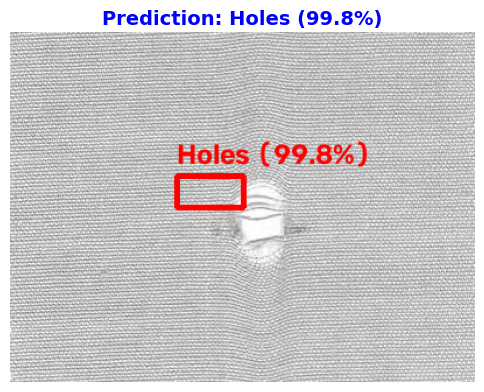

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving oil spot.jpg to oil spot.jpg


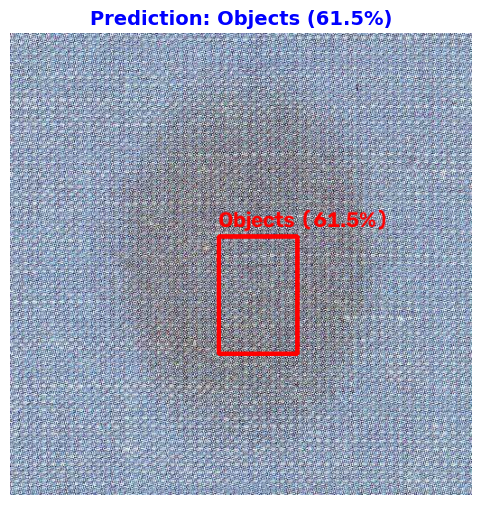

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving thred.jfif to thred.jfif


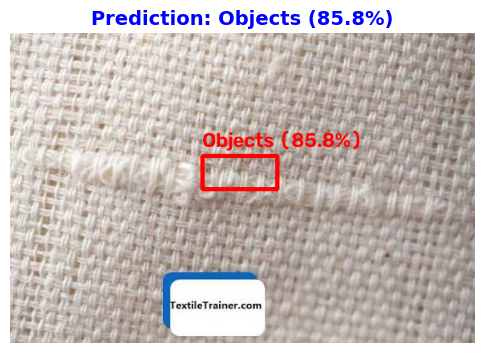

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving neeee.jfif to neeee.jfif


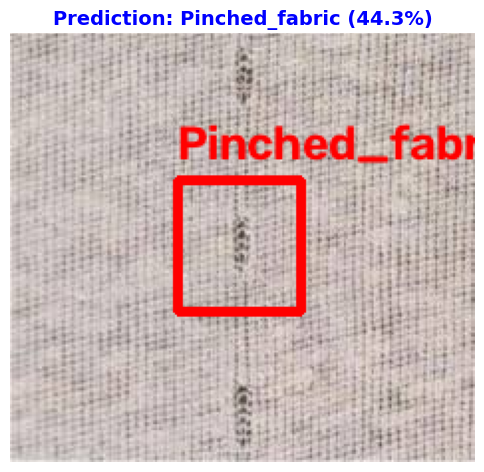

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving 20260713_161436.jpg to 20260713_161436.jpg


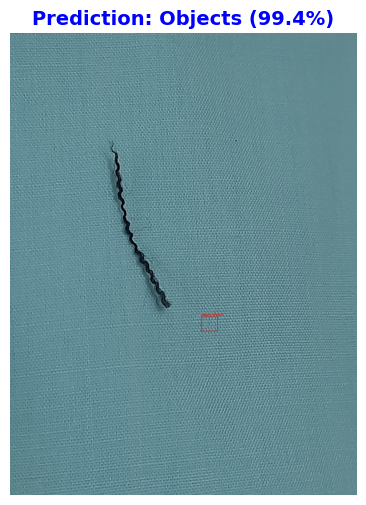

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving 20260713_120732.jpg to 20260713_120732.jpg


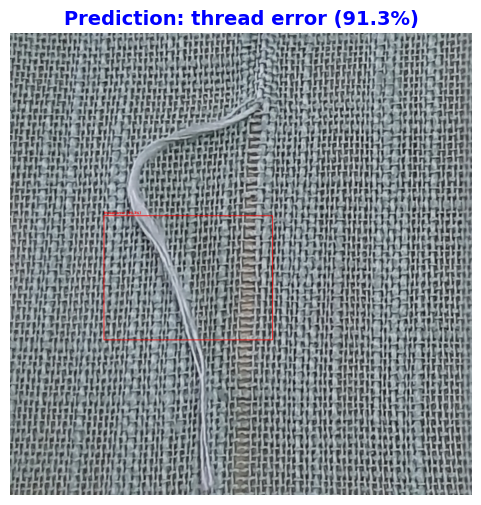

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving IMG_20260716_093001.jpg to IMG_20260716_093001.jpg


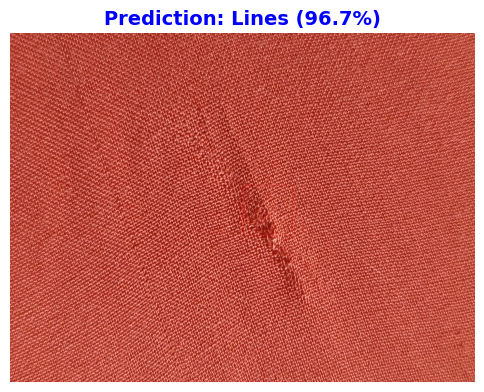

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving IMG_20260715_083016.jpg to IMG_20260715_083016.jpg


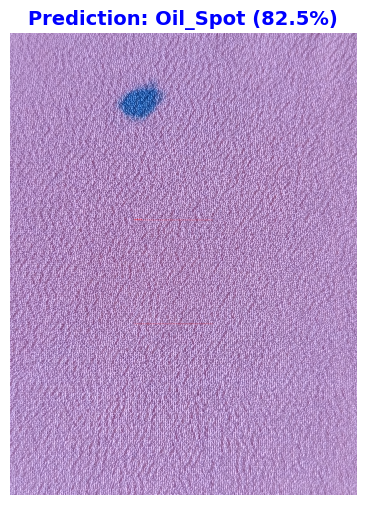

In [ ]:
from google.colab import files
import cv2

if data_path:
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)

            class_preds = predictions[0][0]
            bbox_preds = predictions[1][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0]*original_w, bbox_preds[1]*original_h
            w, h = bbox_preds[2]*original_w, bbox_preds[3]*original_h

            x_min, y_min = int(x_center - (w/2)), int(y_center - (h/2))
            x_max, y_max = int(x_center + (w/2)), int(y_center + (h/2))

            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()